### 학습목표
- pandas 라이브러리 개념과 기본 사용방법 익히기!

### pandas
- 행과 열의 구조를 가지는 데이터를 다룰 때 사용하는 라이브러리
- pandas 데이터
  - Series : 1차원 데이터구조, 인덱스랑 값이 1:1로 대응하는 데이터
  - DataFrame : 2차원 데이터구조, 행과 열로 구성하는 값을 가지는 데이터

In [48]:
#  라이브러리 불러오기
import pandas as pd


In [49]:
# Series 생성
# pd.Series(값)
pd.Series('a')# tab -> 자동완성 alt + shift + ↓ 아래칸으로 복사
pd.Series(['지후','유진','선혜'])
pd.Series(['지후','유진','선혜'], name = '우리반')
pd.Series(['지후','유진','선혜'], index = ['001','002','003'],name = '우리반')

001    지후
002    유진
003    선혜
Name: 우리반, dtype: object

### Series 연산

In [50]:
student = ['하영',24,'INTP']

s = pd.Series(student)

print(s)

k = {
    '이름' : '하영',
    '나이' : 24,
    'MBTI' : 'INTP'
}

b = pd.Series(k)

print(b)

A = ('하영',24,'INTP')

a = pd.Series(A)

a

0      하영
1      24
2    INTP
dtype: object
이름        하영
나이        24
MBTI    INTP
dtype: object


0      하영
1      24
2    INTP
dtype: object

In [51]:
# 딕셔너리 -> {} key, value
# 변수명 = {포켓몬이름 : 경험치}
# 피카츄, 꼬북이, 파이리, 잠만보

data = {'피카츄' : 1256,'마자용' : 1200 , '꼬북이' : 2542 , '파이리' : 9585 , '잠만보' : 100}

pokemon = pd.Series(data)

In [52]:
# 레벨업 조건

data2 =  {'피카츄' : 1500, '꼬북이' : 3000 , '잠만보' : 10000 , '잠만보' : 300}

data2

pokemon_up = pd.Series(data2)

In [53]:
# 레벨업에 필요한 경험치 -> result 
result = pokemon_up - pokemon

result

꼬북이    458.0
마자용      NaN
잠만보    200.0
파이리      NaN
피카츄    244.0
dtype: float64

### 결측치 처리방법

In [54]:
# 결측치 확인
# 변수명.isnull() -> 결과는 논리형

result.isnull()


꼬북이    False
마자용     True
잠만보    False
파이리     True
피카츄    False
dtype: bool

In [55]:
# 비어 있는 값만 출력 -> 조건 -> 불리언 인덱싱

result[result.isnull()]

마자용   NaN
파이리   NaN
dtype: float64

In [56]:
result.notnull()

result[result.notnull()]

꼬북이    458.0
잠만보    200.0
피카츄    244.0
dtype: float64

In [57]:
result[~result.isnull()]

꼬북이    458.0
잠만보    200.0
피카츄    244.0
dtype: float64

In [58]:
# Series 데이터 갱신, 추가, 삭제 
# 데이터 업데이트 !!!
result['피카츄'] = 1400

In [59]:
result

꼬북이     458.0
마자용       NaN
잠만보     200.0
파이리       NaN
피카츄    1400.0
dtype: float64

In [60]:
# 데이터의 추가
result['푸린'] = 200

In [61]:
result

꼬북이     458.0
마자용       NaN
잠만보     200.0
파이리       NaN
피카츄    1400.0
푸린      200.0
dtype: float64

In [62]:
# 데이터의 삭제
del result['꼬북이']

In [63]:
result

마자용       NaN
잠만보     200.0
파이리       NaN
피카츄    1400.0
푸린      200.0
dtype: float64

In [64]:
# 데이터의 결측치 채우기!
# fillna() -> 원본데이터에 영향을 미치지 않는다!

result = result.fillna(0)

In [65]:
result

마자용       0.0
잠만보     200.0
파이리       0.0
피카츄    1400.0
푸린      200.0
dtype: float64

### DataFrame 생성하기
#### DataFrame : 행과 열을 가지는 2차원 데이터

In [66]:
team = pd.DataFrame(
    [
        ['태곤','ISTP'],
        ['예진','ISTJ'],
        ['태헌','INTP'],
        ['강민','ENFP']
    ], columns = ['이름', 'MBTI'],
    index = ['001','002','003','004']
)
team

,이름,MBTI
001,태곤,ISTP
002,예진,ISTJ
003,태헌,INTP
004,강민,ENFP


In [67]:
#DataFrame 전치 -> 행과 열을 뒤집는것
team.T

,001,002,003,004
이름,태곤,예진,태헌,강민
MBTI,ISTP,ISTJ,INTP,ENFP


In [68]:
team = {'이름' : ['태곤','예진','태헌','강민'],
        'MBTI' : ['ISTP','ISTJ','INTP','ENFP']}

team

{'이름': ['태곤', '예진', '태헌', '강민'], 'MBTI': ['ISTP', 'ISTJ', 'INTP', 'ENFP']}

In [69]:
team_dict = {
    '이름': ['태곤', '예진', '태헌', '강민'],
    'MBTI': ['ISTP', 'ISTJ', 'INTP', 'ENFP']
}

team = pd.DataFrame(
    team_dict,
    index=['001', '002', '003', '004']
)

team

# Key -> columns, value -> value 

,이름,MBTI
001,태곤,ISTP
002,예진,ISTJ
003,태헌,INTP
004,강민,ENFP


In [70]:
# 데이터 크기 확인!!
team.shape #->(행,열)  #행 -> axis, 열만으로 계산하고싶을땐 axis =1 로 두고 계산을한다!

(4, 2)

In [71]:
# 인덱스 확인!
team.index

Index(['001', '002', '003', '004'], dtype='object')

In [72]:
# 컬럼값 확인!
team.columns

Index(['이름', 'MBTI'], dtype='object')

In [73]:
# 정보 확인!
team.info()

# Non-Null : 결측치 확인 -> 비어있지 않은 값들의 개수
# Dtype : 데이터 타입

<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, 001 to 004
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   이름      4 non-null      object
 1   MBTI    4 non-null      object
dtypes: object(2)
memory usage: 96.0+ bytes


## 데이터로딩
- csv 파일열기
- pd_read_csv('경로')

In [74]:
# 한글이 들어있는 데이터는 인코딩 작업이 필요하다

# 인코딩 감지 후 데이터 읽어오기

import chardet # 인코딩 감지 라이브리리

with open('./data/hr-info.csv','rb') as f: # 파일 열기, rb(바이트(컴퓨터용 숫자 형태) 로 읽기)

    data = f.read() # 파일을 읽어서 변수 저장

chardet.detect(data) # 인코딩 분석

{'encoding': 'EUC-KR', 'confidence': 0.99, 'language': 'Korean'}

In [75]:
# hr-info.csv
hr_info = pd.read_csv('./data/hr-info.csv',encoding = 'EUC-KR',index_col='EID')

hr_info


,ENAME,GENDER,ORG_CD,POS_CD,AGE,SERVICE_YEAR,EDU_LEVEL,PERFORMANCE_SCORE,SALARY,LAST_PROMO_DT,TRAINING_HOURS,SKILLS,ACTIVE_STATE,HIRE_DATE,RETIRE_DATE,RETIRE_REASON,REHIRE_YN,NATION,ROUNDING_DEDUCTION
EID,,,,,,,,,,,,,,,,,,,
E00206,시이오,M,NaN,P001,49,25,박사 학위,4.50,10200,2024-03-01,240,"Marketing, Salesforce",Y,1999-03-01,NaN,NaN,NaN,KOREA,Y
E00181,나사장,F,NaN,P002,49,24,박사 학위,4.60,9500,2024-03-01,236,"Project Management, Marketing",Y,2000-03-01,NaN,NaN,NaN,KOREA,Y
E00164,난부사장,M,NaN,P003,48,22,박사 학위,4.60,9100,2024-03-01,240,"Salesforce, Data Analysis, Java",Y,2002-03-01,NaN,NaN,NaN,KOREA,Y
E00190,판라다,F,ORG007,P004,47,18,박사 학위,3.51,8500,2024-03-01,96,"Java, Data Analysis, Salesforce",Y,2006-03-01,NaN,NaN,NaN,KOREA,Y
E00209,누훈봉,M,ORG023,P004,47,19,박사 학위,3.38,8600,2023-03-01,66,"Java, Salesforce",Y,2005-03-01,NaN,NaN,NaN,KOREA,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
E00322,부탐회,F,ORG014,P009,23,0,학사 학위,0.00,4500,NaN,4,Java,Y,2024-09-01,NaN,NaN,NaN,KOREA,N
E00389,초두반,F,ORG012,P009,23,0,학사 학위,0.00,4500,NaN,4,"Salesforce, Java",Y,2024-09-01,NaN,NaN,NaN,KOREA,N
E00438,권개득,M,ORG024,P009,23,0,학사 학위,0.00,4500,NaN,4,Python,Y,2024-09-01,NaN,NaN,NaN,KOREA,N


In [76]:
#정보확인
hr_info.info()


<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, E00206 to E00428
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ENAME               200 non-null    object 
 1   GENDER              200 non-null    object 
 2   ORG_CD              197 non-null    object 
 3   POS_CD              200 non-null    object 
 4   AGE                 200 non-null    int64  
 5   SERVICE_YEAR        200 non-null    int64  
 6   EDU_LEVEL           200 non-null    object 
 7   PERFORMANCE_SCORE   200 non-null    float64
 8   SALARY              200 non-null    int64  
 9   LAST_PROMO_DT       182 non-null    object 
 10  TRAINING_HOURS      200 non-null    int64  
 11  SKILLS              200 non-null    object 
 12  ACTIVE_STATE        200 non-null    object 
 13  HIRE_DATE           200 non-null    object 
 14  RETIRE_DATE         49 non-null     object 
 15  RETIRE_REASON       49 non-null     object 
 16  REHIR

In [77]:
# 행, 열 크기 확인

hr_info.shape
#(행,열)

(200, 19)

In [78]:
# 일부 데이터만 살펴보는 방법 : 상위 5개-> head
hr_info.head(1)

,ENAME,GENDER,ORG_CD,POS_CD,AGE,SERVICE_YEAR,EDU_LEVEL,PERFORMANCE_SCORE,SALARY,LAST_PROMO_DT,TRAINING_HOURS,SKILLS,ACTIVE_STATE,HIRE_DATE,RETIRE_DATE,RETIRE_REASON,REHIRE_YN,NATION,ROUNDING_DEDUCTION
EID,,,,,,,,,,,,,,,,,,,
E00206,시이오,M,NaN,P001,49,25,박사 학위,4.5,10200,2024-03-01,240,"Marketing, Salesforce",Y,1999-03-01,NaN,NaN,NaN,KOREA,Y


In [79]:
# 하위 5개만 확인 -> tail
hr_info.tail(1)

,ENAME,GENDER,ORG_CD,POS_CD,AGE,SERVICE_YEAR,EDU_LEVEL,PERFORMANCE_SCORE,SALARY,LAST_PROMO_DT,TRAINING_HOURS,SKILLS,ACTIVE_STATE,HIRE_DATE,RETIRE_DATE,RETIRE_REASON,REHIRE_YN,NATION,ROUNDING_DEDUCTION
EID,,,,,,,,,,,,,,,,,,,
E00428,을충나,F,ORG003,P009,24,0,학사 학위,0.0,4500,NaN,4,"Data Analysis, Python, Marketing",Y,2024-09-01,NaN,NaN,NaN,KOREA,N


### 데이터 색인 (기초)
- DataFrame에서 데이터를 추출하는방법에 대해서 알아보자

- 열(column) 가져오기
    - 열인덱싱

In [80]:
# 직원 이름 컬럼 추출("ENAME") -> 인덱싱

# 변수명 ['컬럼명']
hr_info ['ENAME']

EID
E00206     시이오
E00181     나사장
E00164    난부사장
E00190     판라다
E00209     누훈봉
          ... 
E00322     부탐회
E00389     초두반
E00438     권개득
E00304     탐출조
E00428     을충나
Name: ENAME, Length: 200, dtype: object

# 📊 인사 데이터 컬럼 설명

본 데이터셋은 총 **200명의 직원 인사 정보**를 포함하고 있으며,  
인적 사항, 조직 정보, 근무 이력, 성과·보상, 교육, 퇴직 이력 등  
전반적인 인사 관리 데이터를 다루고 있다.

---

## 🧑 기본 인적 정보

| 컬럼명 | 설명 |
|------|------|
| ENAME | 직원 이름 |
| GENDER | 성별 |
| AGE | 나이 |
| NATION | 국적 |

---

## 🏢 조직 및 직무 정보

| 컬럼명 | 설명 |
|------|------|
| ORG_CD | 소속 조직 코드 (일부 결측치 존재) |
| POS_CD | 직급 코드 |
| EDU_LEVEL | 최종 학력 수준 |

---

## 📅 근무 이력 및 재직 상태

| 컬럼명 | 설명 |
|------|------|
| HIRE_DATE | 입사일 |
| SERVICE_YEAR | 근속 연수 |
| ACTIVE_STATE | 재직 상태 (재직, 휴직, 퇴직 등) |
| LAST_PROMO_DT | 최근 승진일 (일부 결측치 존재) |

---

## 📈 성과 및 보상 정보

| 컬럼명 | 설명 |
|------|------|
| PERFORMANCE_SCORE | 성과 평가 점수 (float) |
| SALARY | 급여 |
| ROUNDING_DEDUCTION | 급여 반올림 또는 공제 여부 |

---

## 📚 교육 및 역량 정보

| 컬럼명 | 설명 |
|------|------|
| TRAINING_HOURS | 누적 교육 이수 시간 |
| SKILLS | 보유 기술 또는 역량 (문자열 형태) |

---

## 🚪 퇴직 및 재입사 정보  
※ 퇴직자에 한해 값이 존재하며, 재직자의 경우 결측치로 구성됨

| 컬럼명 | 설명 |
|------|------|
| RETIRE_DATE | 퇴직일 |
| RETIRE_REASON | 퇴직 사유 |
| REHIRE_YN | 재입사 여부 |

---

In [81]:
# 직원이름[ENAME], 나이[AGE] -> 2개 컬럼 함께 추출

hr_info[['ENAME' , 'AGE']]

,ENAME,AGE
EID,,
E00206,시이오,49
E00181,나사장,49
E00164,난부사장,48
E00190,판라다,47
E00209,누훈봉,47
...,...,...
E00322,부탐회,23
E00389,초두반,23
E00438,권개득,23


In [82]:
hr_info[['ENAME']]

,ENAME
EID,
E00206,시이오
E00181,나사장
E00164,난부사장
E00190,판라다
E00209,누훈봉
...,...
E00322,부탐회
E00389,초두반
E00438,권개득


- 행 가져오기~
  
      - 주의
      -행단위로는 슬라이싱만 가능!!

In [227]:
# hr_info[['E00206']]은 안된다. 저 방식은 열을 불러올때만 가능하기때문

- DataFrame 연산
  - 행단위, 열단위의 연산이 가능

In [148]:
# 연봉데이터 가져와서 계산해보기

hr_info[['SALARY']]/12

,SALARY
EID,
E00206,850.00
E00181,791.67
E00164,758.33
E00190,708.33
E00209,716.67
...,...
E00322,375.00
E00389,375.00
E00438,375.00


In [96]:
hr_info.columns

Index(['ENAME', 'GENDER', 'ORG_CD', 'POS_CD', 'AGE', 'SERVICE_YEAR',
       'EDU_LEVEL', 'PERFORMANCE_SCORE', 'SALARY', 'LAST_PROMO_DT',
       'TRAINING_HOURS', 'SKILLS', 'ACTIVE_STATE', 'HIRE_DATE', 'RETIRE_DATE',
       'RETIRE_REASON', 'REHIRE_YN', 'NATION', 'ROUNDING_DEDUCTION'],
      dtype='object')

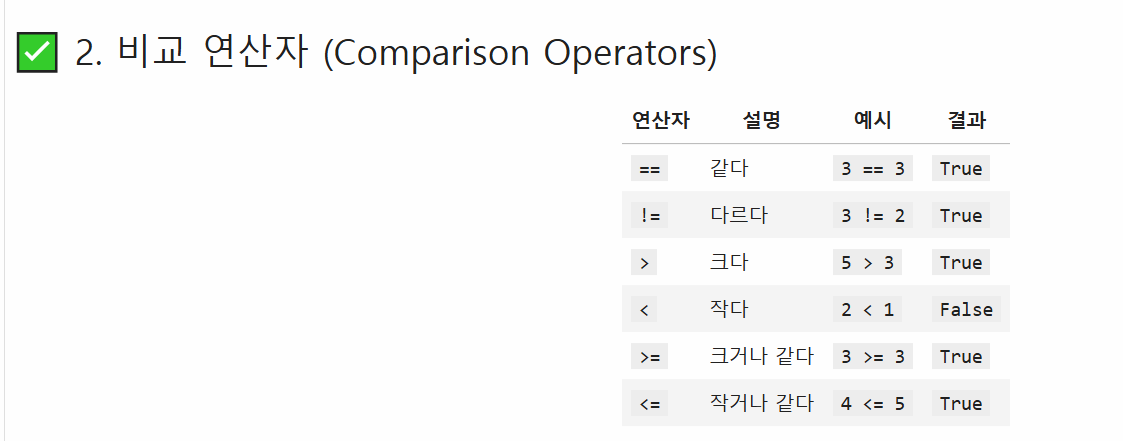

In [ ]:
# 비교연산 연봉이 5천 이상인 데이터 가져오기

In [133]:
a = hr_info['SALARY'] > 5000

EID
E00206     True
E00181     True
E00164     True
E00190     True
E00209     True
          ...  
E00322    False
E00389    False
E00438    False
E00304    False
E00428    False
Name: SALARY, Length: 200, dtype: bool

### Boolean 색인 (불리언인덱싱)
- "조건"을 중심으로 데이터를 추출하는 방법
- 비교연산의 결과가 True 인 값의 행과 열을 추출
- 데이터변수명[조건]

In [146]:
hr_info[hr_info['SALARY'] >= 8000]

,ENAME,GENDER,ORG_CD,POS_CD,AGE,SERVICE_YEAR,EDU_LEVEL,PERFORMANCE_SCORE,SALARY,LAST_PROMO_DT,TRAINING_HOURS,SKILLS,ACTIVE_STATE,HIRE_DATE,RETIRE_DATE,RETIRE_REASON,REHIRE_YN,NATION,ROUNDING_DEDUCTION
EID,,,,,,,,,,,,,,,,,,,
E00206,시이오,M,NaN,P001,49,25,박사 학위,4.50,10200,2024-03-01,240,"Marketing, Salesforce",Y,1999-03-01,NaN,NaN,NaN,KOREA,Y
E00181,나사장,F,NaN,P002,49,24,박사 학위,4.60,9500,2024-03-01,236,"Project Management, Marketing",Y,2000-03-01,NaN,NaN,NaN,KOREA,Y
E00164,난부사장,M,NaN,P003,48,22,박사 학위,4.60,9100,2024-03-01,240,"Salesforce, Data Analysis, Java",Y,2002-03-01,NaN,NaN,NaN,KOREA,Y
E00190,판라다,F,ORG007,P004,47,18,박사 학위,3.51,8500,2024-03-01,96,"Java, Data Analysis, Salesforce",Y,2006-03-01,NaN,NaN,NaN,KOREA,Y
E00209,누훈봉,M,ORG023,P004,47,19,박사 학위,3.38,8600,2023-03-01,66,"Java, Salesforce",Y,2005-03-01,NaN,NaN,NaN,KOREA,Y
E00242,규모사,M,ORG027,P004,47,18,학사 학위,2.22,8300,2024-03-01,0,"Java, Salesforce, Python",Y,2006-03-01,NaN,NaN,NaN,KOREA,Y
E00298,포난서,F,ORG021,P004,47,19,석사 학위,3.63,8500,2023-03-01,47,Data Analysis,Y,2005-03-01,NaN,NaN,NaN,KOREA,Y
E00487,고명초,F,ORG014,P004,47,20,석사 학위,1.81,8600,2022-03-01,49,"Marketing, Salesforce, Project Management",Y,2004-03-01,NaN,NaN,NaN,Japan,Y
E00169,제언로,M,ORG004,P004,48,20,학사 학위,3.90,8500,2022-03-01,32,"Salesforce, Data Analysis, Python",Y,2004-03-01,NaN,NaN,NaN,KOREA,Y


In [ ]:
# 5000만원 이하인 사람만 뽑아주세요

In [160]:
hr_info[hr_info['SALARY'] <= 5000][['ENAME','GENDER']]

,ENAME,GENDER
EID,,
E00165,내감반,M
E00171,표화선,F
E00235,대해래,M
E00282,문차택,F
E00337,번함중,M
...,...,...
E00322,부탐회,F
E00389,초두반,F
E00438,권개득,M


In [161]:
hr_info.loc[hr_info['SALARY'] <= 5000, ['ENAME']]

,ENAME
EID,
E00165,내감반
E00171,표화선
E00235,대해래
E00282,문차택
E00337,번함중
...,...
E00322,부탐회
E00389,초두반
E00438,권개득


In [ ]:
# 성인인 남자(M)인 사람만 출력
#GENDER

In [178]:
hr_info[hr_info['GENDER'] == 'M']

,ENAME,GENDER,ORG_CD,POS_CD,AGE,SERVICE_YEAR,EDU_LEVEL,PERFORMANCE_SCORE,SALARY,LAST_PROMO_DT,TRAINING_HOURS,SKILLS,ACTIVE_STATE,HIRE_DATE,RETIRE_DATE,RETIRE_REASON,REHIRE_YN,NATION,ROUNDING_DEDUCTION
EID,,,,,,,,,,,,,,,,,,,
E00206,시이오,M,NaN,P001,49,25,박사 학위,4.50,10200,2024-03-01,240,"Marketing, Salesforce",Y,1999-03-01,NaN,NaN,NaN,KOREA,Y
E00164,난부사장,M,NaN,P003,48,22,박사 학위,4.60,9100,2024-03-01,240,"Salesforce, Data Analysis, Java",Y,2002-03-01,NaN,NaN,NaN,KOREA,Y
E00209,누훈봉,M,ORG023,P004,47,19,박사 학위,3.38,8600,2023-03-01,66,"Java, Salesforce",Y,2005-03-01,NaN,NaN,NaN,KOREA,Y
E00242,규모사,M,ORG027,P004,47,18,학사 학위,2.22,8300,2024-03-01,0,"Java, Salesforce, Python",Y,2006-03-01,NaN,NaN,NaN,KOREA,Y
E00169,제언로,M,ORG004,P004,48,20,학사 학위,3.90,8500,2022-03-01,32,"Salesforce, Data Analysis, Python",Y,2004-03-01,NaN,NaN,NaN,KOREA,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
E00364,사디길,M,ORG027,P009,22,0,고등학교 졸업,0.00,4500,NaN,4,Java,Y,2024-03-01,NaN,NaN,NaN,KOREA,N
E00248,말만양,M,ORG017,P009,23,0,학사 학위,0.00,4500,NaN,4,"Project Management, Salesforce, Java",Y,2024-09-01,NaN,NaN,NaN,KOREA,N
E00250,비식백,M,ORG019,P009,23,0,학사 학위,0.00,4500,NaN,4,"Project Management, Python",Y,2024-09-01,NaN,NaN,NaN,KOREA,N


In [162]:
hr_info.columns

Index(['ENAME', 'GENDER', 'ORG_CD', 'POS_CD', 'AGE', 'SERVICE_YEAR',
       'EDU_LEVEL', 'PERFORMANCE_SCORE', 'SALARY', 'LAST_PROMO_DT',
       'TRAINING_HOURS', 'SKILLS', 'ACTIVE_STATE', 'HIRE_DATE', 'RETIRE_DATE',
       'RETIRE_REASON', 'REHIRE_YN', 'NATION', 'ROUNDING_DEDUCTION'],
      dtype='object')

In [168]:
hr_info.loc[hr_info['GENDER'] == 'M', ['SALARY']]

,SALARY
EID,
E00206,10200
E00164,9100
E00209,8600
E00242,8300
E00169,8500
...,...
E00364,4500
E00248,4500
E00250,4500


In [170]:
df = hr_info.loc[hr_info['GENDER'] == 'M', ['SALARY']]

In [175]:
int(df['SALARY'].sum())

701400

In [ ]:
# EDU_LEVEL
# 학위가 석사인 사람 추출 -> 불리언인덱싱

In [176]:
hr_info[hr_info['EDU_LEVEL'] == '석사 학위']

,ENAME,GENDER,ORG_CD,POS_CD,AGE,SERVICE_YEAR,EDU_LEVEL,PERFORMANCE_SCORE,SALARY,LAST_PROMO_DT,TRAINING_HOURS,SKILLS,ACTIVE_STATE,HIRE_DATE,RETIRE_DATE,RETIRE_REASON,REHIRE_YN,NATION,ROUNDING_DEDUCTION
EID,,,,,,,,,,,,,,,,,,,
E00298,포난서,F,ORG021,P004,47,19,석사 학위,3.63,8500,2023-03-01,47,Data Analysis,Y,2005-03-01,NaN,NaN,NaN,KOREA,Y
E00487,고명초,F,ORG014,P004,47,20,석사 학위,1.81,8600,2022-03-01,49,"Marketing, Salesforce, Project Management",Y,2004-03-01,NaN,NaN,NaN,Japan,Y
E00346,루신디,F,ORG011,P004,48,19,석사 학위,1.25,8500,2023-03-01,83,Python,Y,2005-03-01,NaN,NaN,NaN,USA,Y
E00167,명묵말,M,ORG013,P005,42,12,석사 학위,3.88,7300,2024-03-01,46,Salesforce,Y,2012-03-01,NaN,NaN,NaN,KOREA,Y
E00207,초디소,M,ORG030,P005,41,11,석사 학위,4.38,7200,2023-03-01,17,"Java, Project Management",N,2011-03-01,2022-02-28,이직,N,KOREA,Y
E00260,녹덕익,M,ORG002,P005,40,14,석사 학위,2.71,7500,2022-03-01,62,Salesforce,Y,2010-03-01,NaN,NaN,NaN,KOREA,Y
E00323,묵단언,F,ORG022,P005,40,11,석사 학위,2.95,7200,2023-03-01,79,Data Analysis,N,2011-03-01,2023-02-28,개인 사유,Y,Japan,Y
E00445,속묵우,M,ORG002,P006,35,9,석사 학위,3.06,7000,2022-03-01,87,Salesforce,N,2015-03-01,2024-02-29,이직,N,UK,Y
E00176,자웅유,F,ORG003,P006,36,9,석사 학위,1.16,7000,2022-03-01,2,Java,Y,2015-03-01,NaN,NaN,NaN,KOREA,Y


In [179]:
hr_info[hr_info['EDU_LEVEL'] == '박사 학위']

,ENAME,GENDER,ORG_CD,POS_CD,AGE,SERVICE_YEAR,EDU_LEVEL,PERFORMANCE_SCORE,SALARY,LAST_PROMO_DT,TRAINING_HOURS,SKILLS,ACTIVE_STATE,HIRE_DATE,RETIRE_DATE,RETIRE_REASON,REHIRE_YN,NATION,ROUNDING_DEDUCTION
EID,,,,,,,,,,,,,,,,,,,
E00206,시이오,M,NaN,P001,49,25,박사 학위,4.50,10200,2024-03-01,240,"Marketing, Salesforce",Y,1999-03-01,NaN,NaN,NaN,KOREA,Y
E00181,나사장,F,NaN,P002,49,24,박사 학위,4.60,9500,2024-03-01,236,"Project Management, Marketing",Y,2000-03-01,NaN,NaN,NaN,KOREA,Y
E00164,난부사장,M,NaN,P003,48,22,박사 학위,4.60,9100,2024-03-01,240,"Salesforce, Data Analysis, Java",Y,2002-03-01,NaN,NaN,NaN,KOREA,Y
E00190,판라다,F,ORG007,P004,47,18,박사 학위,3.51,8500,2024-03-01,96,"Java, Data Analysis, Salesforce",Y,2006-03-01,NaN,NaN,NaN,KOREA,Y
E00209,누훈봉,M,ORG023,P004,47,19,박사 학위,3.38,8600,2023-03-01,66,"Java, Salesforce",Y,2005-03-01,NaN,NaN,NaN,KOREA,Y
E00294,중우방,F,ORG021,P004,48,19,박사 학위,2.56,8600,2023-03-01,12,"Python, Salesforce, Java",Y,2005-03-01,NaN,NaN,NaN,KOREA,Y
E00411,구류길,M,ORG004,P004,48,18,박사 학위,4.87,8500,2024-03-01,37,"Data Analysis, Java, Python",Y,2006-03-01,NaN,NaN,NaN,USA,Y
E00210,봉묵정,M,ORG006,P005,41,14,박사 학위,2.65,7600,2022-03-01,46,"Salesforce, Marketing, Data Analysis",Y,2010-03-01,NaN,NaN,NaN,KOREA,Y
E00258,처록신,M,ORG016,P005,40,13,박사 학위,1.97,7500,2023-03-01,12,"Salesforce, Data Analysis, Project Management",Y,2011-03-01,NaN,NaN,NaN,KOREA,Y


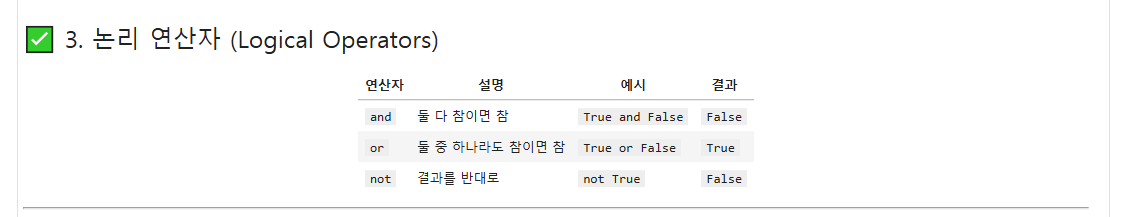

In [190]:
hr_info[((hr_info['EDU_LEVEL'] == '석사 학위') | (hr_info['EDU_LEVEL'] == '박사 학위')) & (hr_info['GENDER'] == 'M')]

,ENAME,GENDER,ORG_CD,POS_CD,AGE,SERVICE_YEAR,EDU_LEVEL,PERFORMANCE_SCORE,SALARY,LAST_PROMO_DT,TRAINING_HOURS,SKILLS,ACTIVE_STATE,HIRE_DATE,RETIRE_DATE,RETIRE_REASON,REHIRE_YN,NATION,ROUNDING_DEDUCTION
EID,,,,,,,,,,,,,,,,,,,
E00206,시이오,M,NaN,P001,49,25,박사 학위,4.50,10200,2024-03-01,240,"Marketing, Salesforce",Y,1999-03-01,NaN,NaN,NaN,KOREA,Y
E00164,난부사장,M,NaN,P003,48,22,박사 학위,4.60,9100,2024-03-01,240,"Salesforce, Data Analysis, Java",Y,2002-03-01,NaN,NaN,NaN,KOREA,Y
E00209,누훈봉,M,ORG023,P004,47,19,박사 학위,3.38,8600,2023-03-01,66,"Java, Salesforce",Y,2005-03-01,NaN,NaN,NaN,KOREA,Y
E00411,구류길,M,ORG004,P004,48,18,박사 학위,4.87,8500,2024-03-01,37,"Data Analysis, Java, Python",Y,2006-03-01,NaN,NaN,NaN,USA,Y
E00167,명묵말,M,ORG013,P005,42,12,석사 학위,3.88,7300,2024-03-01,46,Salesforce,Y,2012-03-01,NaN,NaN,NaN,KOREA,Y
E00207,초디소,M,ORG030,P005,41,11,석사 학위,4.38,7200,2023-03-01,17,"Java, Project Management",N,2011-03-01,2022-02-28,이직,N,KOREA,Y
E00210,봉묵정,M,ORG006,P005,41,14,박사 학위,2.65,7600,2022-03-01,46,"Salesforce, Marketing, Data Analysis",Y,2010-03-01,NaN,NaN,NaN,KOREA,Y
E00258,처록신,M,ORG016,P005,40,13,박사 학위,1.97,7500,2023-03-01,12,"Salesforce, Data Analysis, Project Management",Y,2011-03-01,NaN,NaN,NaN,KOREA,Y
E00260,녹덕익,M,ORG002,P005,40,14,석사 학위,2.71,7500,2022-03-01,62,Salesforce,Y,2010-03-01,NaN,NaN,NaN,KOREA,Y


In [196]:
# 학위가 석사 이상인 사람들 추출 # and, or not -> 한개짜리 비교용
# 리스트 튜플 딕셔너리에서는 & | ~을 쓴다

hr_info[(hr_info["EDU_LEVEL"] == '석사 학위') | (hr_info["EDU_LEVEL"] == '박사 학위')]

,ENAME,GENDER,ORG_CD,POS_CD,AGE,SERVICE_YEAR,EDU_LEVEL,PERFORMANCE_SCORE,SALARY,LAST_PROMO_DT,TRAINING_HOURS,SKILLS,ACTIVE_STATE,HIRE_DATE,RETIRE_DATE,RETIRE_REASON,REHIRE_YN,NATION,ROUNDING_DEDUCTION
EID,,,,,,,,,,,,,,,,,,,
E00206,시이오,M,NaN,P001,49,25,박사 학위,4.50,10200,2024-03-01,240,"Marketing, Salesforce",Y,1999-03-01,NaN,NaN,NaN,KOREA,Y
E00181,나사장,F,NaN,P002,49,24,박사 학위,4.60,9500,2024-03-01,236,"Project Management, Marketing",Y,2000-03-01,NaN,NaN,NaN,KOREA,Y
E00164,난부사장,M,NaN,P003,48,22,박사 학위,4.60,9100,2024-03-01,240,"Salesforce, Data Analysis, Java",Y,2002-03-01,NaN,NaN,NaN,KOREA,Y
E00190,판라다,F,ORG007,P004,47,18,박사 학위,3.51,8500,2024-03-01,96,"Java, Data Analysis, Salesforce",Y,2006-03-01,NaN,NaN,NaN,KOREA,Y
E00209,누훈봉,M,ORG023,P004,47,19,박사 학위,3.38,8600,2023-03-01,66,"Java, Salesforce",Y,2005-03-01,NaN,NaN,NaN,KOREA,Y
E00298,포난서,F,ORG021,P004,47,19,석사 학위,3.63,8500,2023-03-01,47,Data Analysis,Y,2005-03-01,NaN,NaN,NaN,KOREA,Y
E00487,고명초,F,ORG014,P004,47,20,석사 학위,1.81,8600,2022-03-01,49,"Marketing, Salesforce, Project Management",Y,2004-03-01,NaN,NaN,NaN,Japan,Y
E00294,중우방,F,ORG021,P004,48,19,박사 학위,2.56,8600,2023-03-01,12,"Python, Salesforce, Java",Y,2005-03-01,NaN,NaN,NaN,KOREA,Y
E00346,루신디,F,ORG011,P004,48,19,석사 학위,1.25,8500,2023-03-01,83,Python,Y,2005-03-01,NaN,NaN,NaN,USA,Y


### 데이터 색인 (심화)
- 행과 열의 범위를 설정하여 데이터를 추출

##### 인덱서(loc, iloc)
- df.loc[행범위, 열범위] : 컬럼명, 인덱스명 통해서 추출
- df.iloc[행범위, 열범위] : 인덱스 번호를 통해서 추출 / 끝번호 + 1
- 문제 풀어보자!
  - 행범위: E00206:E00164 , 열범위 : ENAME:AGE

In [199]:
df = hr_info

df.loc['E00206':'E00164','ENAME':'AGE']

,ENAME,GENDER,ORG_CD,POS_CD,AGE
EID,,,,,
E00206,시이오,M,NaN,P001,49
E00181,나사장,F,NaN,P002,49
E00164,난부사장,M,NaN,P003,48


In [207]:
# 행범위: E00206, E00164 , 열범위 : ENAME,AGE
# df.iloc 는 행번호, 열번호 이용!
df.iloc[0:3,0:5]

,ENAME,GENDER,ORG_CD,POS_CD,AGE
EID,,,,,
E00206,시이오,M,NaN,P001,49
E00181,나사장,F,NaN,P002,49
E00164,난부사장,M,NaN,P003,48


In [213]:
#iloc 이용
# 모든 사람의 AGE ~ SALARY

df.iloc[ : ,4:9]

,AGE,SERVICE_YEAR,EDU_LEVEL,PERFORMANCE_SCORE,SALARY
EID,,,,,
E00206,49,25,박사 학위,4.50,10200
E00181,49,24,박사 학위,4.60,9500
E00164,48,22,박사 학위,4.60,9100
E00190,47,18,박사 학위,3.51,8500
E00209,47,19,박사 학위,3.38,8600
...,...,...,...,...,...
E00322,23,0,학사 학위,0.00,4500
E00389,23,0,학사 학위,0.00,4500
E00438,23,0,학사 학위,0.00,4500


In [226]:
# 생략
# df.loc[행범위, 열범위] -> 열범위를 안적으면 전체를 불러온다

df.loc["E00206":"E00209"]

,ENAME,GENDER,ORG_CD,POS_CD,AGE,SERVICE_YEAR,EDU_LEVEL,PERFORMANCE_SCORE,SALARY,LAST_PROMO_DT,TRAINING_HOURS,SKILLS,ACTIVE_STATE,HIRE_DATE,RETIRE_DATE,RETIRE_REASON,REHIRE_YN,NATION,ROUNDING_DEDUCTION
EID,,,,,,,,,,,,,,,,,,,
E00206,시이오,M,NaN,P001,49,25,박사 학위,4.50,10200,2024-03-01,240,"Marketing, Salesforce",Y,1999-03-01,NaN,NaN,NaN,KOREA,Y
E00181,나사장,F,NaN,P002,49,24,박사 학위,4.60,9500,2024-03-01,236,"Project Management, Marketing",Y,2000-03-01,NaN,NaN,NaN,KOREA,Y
E00164,난부사장,M,NaN,P003,48,22,박사 학위,4.60,9100,2024-03-01,240,"Salesforce, Data Analysis, Java",Y,2002-03-01,NaN,NaN,NaN,KOREA,Y
E00190,판라다,F,ORG007,P004,47,18,박사 학위,3.51,8500,2024-03-01,96,"Java, Data Analysis, Salesforce",Y,2006-03-01,NaN,NaN,NaN,KOREA,Y
E00209,누훈봉,M,ORG023,P004,47,19,박사 학위,3.38,8600,2023-03-01,66,"Java, Salesforce",Y,2005-03-01,NaN,NaN,NaN,KOREA,Y


In [231]:
df.loc[['E00210']]

,ENAME,GENDER,ORG_CD,POS_CD,AGE,SERVICE_YEAR,EDU_LEVEL,PERFORMANCE_SCORE,SALARY,LAST_PROMO_DT,TRAINING_HOURS,SKILLS,ACTIVE_STATE,HIRE_DATE,RETIRE_DATE,RETIRE_REASON,REHIRE_YN,NATION,ROUNDING_DEDUCTION
EID,,,,,,,,,,,,,,,,,,,
E00210,봉묵정,M,ORG006,P005,41,14,박사 학위,2.65,7600,2022-03-01,46,"Salesforce, Marketing, Data Analysis",Y,2010-03-01,NaN,NaN,NaN,KOREA,Y


In [192]:
hr_info.columns

Index(['ENAME', 'GENDER', 'ORG_CD', 'POS_CD', 'AGE', 'SERVICE_YEAR',
       'EDU_LEVEL', 'PERFORMANCE_SCORE', 'SALARY', 'LAST_PROMO_DT',
       'TRAINING_HOURS', 'SKILLS', 'ACTIVE_STATE', 'HIRE_DATE', 'RETIRE_DATE',
       'RETIRE_REASON', 'REHIRE_YN', 'NATION', 'ROUNDING_DEDUCTION'],
      dtype='object')

In [85]:
data = {
    1: {'이름': '태곤', 'MBTI': 'ISTP'},
    2: {'이름': '예진', 'MBTI': 'ISTJ'}
}

data

a = pd.DataFrame(
    data
)
a

,1,2
이름,태곤,예진
MBTI,ISTP,ISTJ


In [91]:
dat = [
    ['태곤','예진'],
    ['ISTP','ISTJ'],
]

b= pd.DataFrame(
    dat,
    index = ['이름', 'MBTI']
)

b

,0,1
이름,태곤,예진
MBTI,ISTP,ISTJ


In [89]:
b.index

Index(['이름', 'MBTI'], dtype='object')